In [1]:
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.path.join(os.getcwd(), ".."), ".."))
sys.path.append(parent_dir)

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import Voronoi, voronoi_plot_2d
from scipy.special import gamma
from matplotlib.collections import PatchCollection

from data_generation.simulations.grid import *

In [9]:
import numpy as np

a = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
b = a.reshape(-1, a.shape[-1])
c = np.array([[0, 1], [2, 3]])
# Repeat c vertically 3 times to get the desired shape
c_repeated = np.tile(c, (4, 1))
print(c_repeated)

[[0 1]
 [2 3]
 [0 1]
 [2 3]
 [0 1]
 [2 3]
 [0 1]
 [2 3]]


In [18]:
def estimate_poisson_radius(n_points, efficiency=0.75, area = 1):
    return 2* np.sqrt(efficiency * area / (np.pi * n_points))

r = estimate_poisson_radius(1000, efficiency = 0.475, area = 100)
print(f"Estimated r ≈ {r:.4f}")

Estimated r ≈ 0.2459


In [20]:
bounds = np.array([[0, 10], [0, 10]])

In [ ]:
first_entries = bounds[:, 0].tolist()
print(first_entries)

[0 0]


In [21]:
def estimate_poisson_radius(N, bounds, efficiency=0.75):
    """
    Estimate Poisson Disk Sampling radius r for N points in a d-dimensional box.

    Parameters:
    - N : int
        Desired number of points
    - bounds : list of [low, high] for each dimension
        Example: [[0, 1], [0, 1]] for 2D unit square
    - efficiency : float
        Packing efficiency factor (0.7–0.8 for Poisson disk in 2D)

    Returns:
    - r : float
        Estimated minimum distance between points
    """
    bounds = np.array(bounds)
    d = bounds.shape[0]
    volume = np.prod(bounds[:, 1] - bounds[:, 0])
    unit_ball_volume = np.pi ** (d / 2) / gamma(d / 2 + 1)
    r = 2*((efficiency * volume) / (N * unit_ball_volume)) ** (1 / d)
    return r

r = estimate_poisson_radius(1000, bounds, efficiency=0.35)
print(f"Estimated r ≈ {r:.4f}")

Estimated r ≈ 0.2111


In [24]:
def my_estimation_poisson_radius(n_points, efficiency=0.75, side_length = 1, dim=2):
    return efficiency * side_length / (np.round(n_points ** (1/dim)) - 1)

r = my_estimation_poisson_radius(1000, side_length = 10, dim=2, efficiency=0.8)

In [25]:
from scipy.stats import qmc
engine = qmc.PoissonDisk(2, radius=r, l_bounds=[0, 0], u_bounds=[10,10])
samples = engine.fill_space() #engine.random(100)
samples = samples + np.array([-10, -10])  # Adjust to bounds
print(f"Number of samples: {len(samples)}")
samples

Number of samples: 909


array([[-7.40018187, -2.51629974],
       [-7.75705639, -2.75058528],
       [-7.09666869, -2.87943126],
       ...,
       [-0.29037507, -9.74901354],
       [-0.0214838 , -9.72343742],
       [-0.5433414 , -9.86083764]])

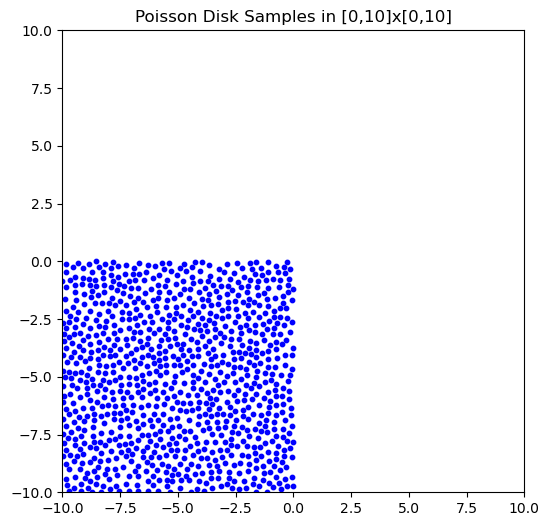

Number of samples: 909


In [29]:

plt.figure(figsize=(6, 6))
plt.scatter(samples[:, 0], samples[:, 1], c='blue', s=10)
plt.xlim(-10,10)
plt.ylim(-10,10)
plt.title("Poisson Disk Samples in [0,10]x[0,10]")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()
print(f"Number of samples: {len(samples)}")



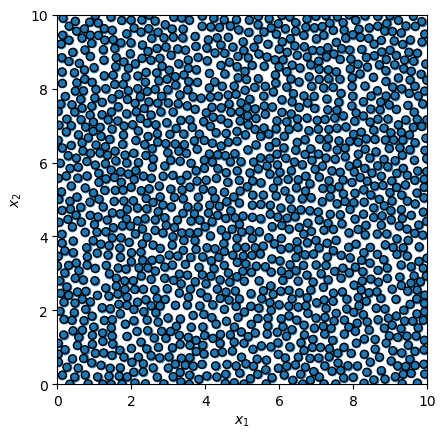

In [24]:
fig, ax = plt.subplots()
_ = ax.scatter(samples[:, 0], samples[:, 1])
circles = [plt.Circle((xi, yi), radius=r/2, fill=False) for xi, yi in samples]
collection = PatchCollection(circles, match_original=True)
ax.add_collection(collection)
_ = ax.set(aspect='equal', xlabel=r'$x_1$', ylabel=r'$x_2$',
           xlim=[0, 10], ylim=[0, 10])

plt.show()

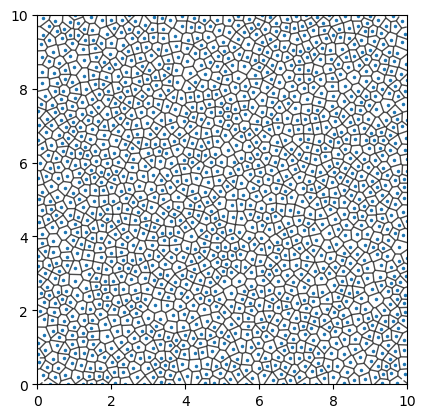

In [25]:
voronoi_plot_2d(Voronoi(samples), show_vertices=False, line_colors='black', line_width=1, line_alpha=0.7, point_size=3)
plt.xlim(bounds[0])
plt.ylim(bounds[1])
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [10]:
len(samples)

17

(165, 2)
(165, 2)
Grid cells: 31


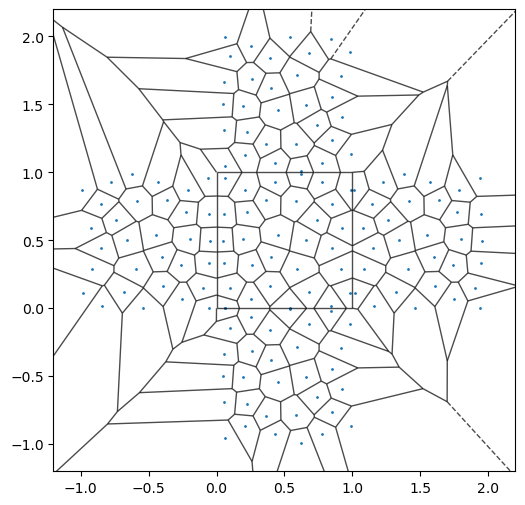

In [19]:
bounds = np.array([[0,1], [0, 1]])
numbercells = 40
grid = VoronoiGrid(bounds, numbercells, center_sampling_type='Poisson_Disk', padding_margin=0.5)
print(f"Grid cells: {grid.numbercells}")
fig = voronoi_plot_2d(grid.voronoi, show_vertices=False, line_colors='black', line_width=1, line_alpha=0.7, point_size=2)
fig.set_size_inches(6, 6)
plt.xlim(-1.2,2.2)
plt.ylim(-1.2,2.2)
plt.gca().set_aspect('equal', adjustable='box')

In [ ]:
a = [grid.voronoi.vertices[region] for region in grid.voronoi.regions if -1 not in region and len(region) > 0]
vertices_array = np.vstack(a)
[np.all((vertex >= grid.tf_bounds[:, 0]) & (vertex <= grid.tf_bounds[:, 1]) for vertex in vertices_array)]

[np.True_]

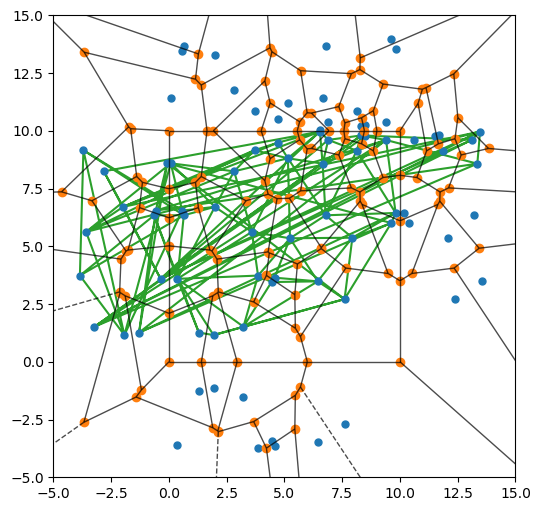

In [55]:
fig = voronoi_plot_2d(grid.voronoi, show_vertices=True, line_colors='black', line_width=1, line_alpha=0.7, point_size=10)
fig.set_size_inches(6, 6)
plt.xlim(-5,15)
plt.ylim(-5,15)
plt.gca().set_aspect('equal', adjustable='box')
points = grid.voronoi.points

plt.triplot(points[:,0], points[:,1], grid.delaunay.simplices)
#for i, (x, y) in enumerate(points):
    ##plt.text(x, y, str(i), fontsize=9, ha='center', va='center', color='black')
#plt.plot(points[:,0], points[:,1], 'o', markersize=15, color='red', alpha=0.5, label='Points')

plt.show()

In [ ]:
np.random.SeedSequence().generate_state(1)[0]

np.uint32(4277983251)

In [5]:
bounds = np.array([[0, 10], [0, 10],[0, 10]])
numbercells = 30
grid = VoronoiGrid(bounds, numbercells, padding_margin=2)

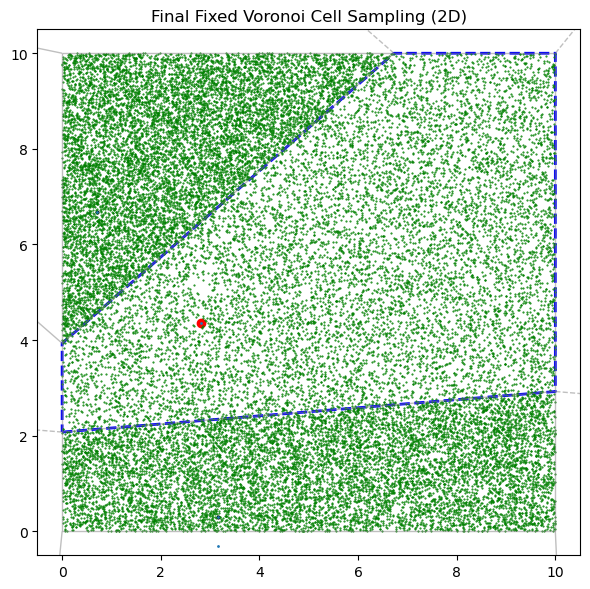

In [ ]:
# Generate 100 random sites and sampler
sampler = grid
# Re-sample from cells
sampled_points = np.array([[sampler.choose_random_point_from_cell(i) for _ in range(10000)] for i in grid.indices] )
# Re-plot in 2D
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(grid.original_sites[:, 0], grid.original_sites[:, 1], 'ko', markersize=2)
ax.plot(grid.original_sites[0, 0],grid.original_sites[0, 1], 'ro', label='Cell Center')
region_index = sampler.voronoi.point_region[0]
region = sampler.voronoi.regions[region_index]
if -1 not in region:
    polygon = [sampler.voronoi.vertices[v] for v in region]
    polygon.append(polygon[0])
    poly = np.array(polygon)
    ax.plot(poly[:, 0], poly[:, 1], 'b--', lw=2, label='Voronoi Cell 0')
for i in range(len(grid.original_sites)):
    ax.plot(sampled_points[i, :, 0], sampled_points[i, :, 1], 'g.', markersize=1, label='Samples')
voronoi_plot_2d(sampler.voronoi, ax=ax, show_vertices=False, line_colors='gray', line_width=1, line_alpha=0.5, point_size=2)

#ax.legend()
ax.set_title("Final Fixed Voronoi Cell Sampling (2D)")
ax.set_xlim([-0.5, 10.5])
ax.set_ylim([-0.5, 10.5])
#plt.axis("equal")
plt.tight_layout()
plt.show()



In [22]:
for (i, j), ridge_vertex_ids in zip(grid.voronoi.ridge_points, grid.voronoi.ridge_vertices):
    print(f"Ridge between points {i} and {j} has vertices {ridge_vertex_ids}")

Ridge between points 0 and 1 has vertices [-1, 0]
Ridge between points 0 and 2 has vertices [-1, 0]
Ridge between points 1 and 2 has vertices [-1, 0]


In [24]:
vor = grid.voronoi
for (i, j), ridge_vertex_ids in zip(vor.ridge_points, vor.ridge_vertices):
    
    ridge_vertices = []
    for idx in ridge_vertex_ids:
        if idx == -1:
            ridge_vertices.append('inf')
        else:
            ridge_vertices.append(vor.vertices[idx])

    print(f"Ridge between points {i} and {j}: vertices {ridge_vertices}")

Ridge between points 0 and 1: vertices ['inf', array([-2.27239486,  1.88411417])]
Ridge between points 0 and 2: vertices ['inf', array([-2.27239486,  1.88411417])]
Ridge between points 1 and 2: vertices ['inf', array([-2.27239486,  1.88411417])]


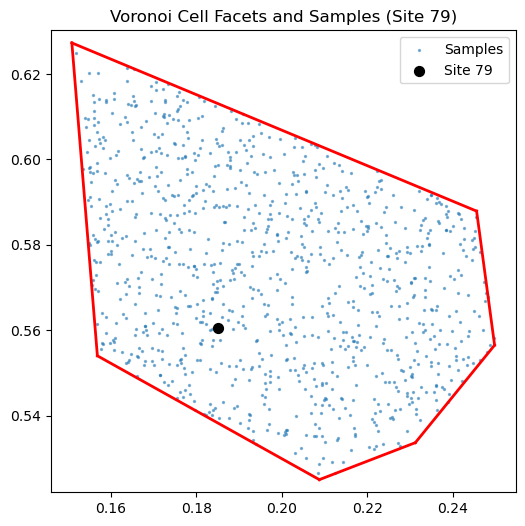

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, KDTree

def dirichlet_random_point(vertices):
    """Uniform sample a point from the simplex defined by 'vertices'."""
    m, d = vertices.shape
    y = -np.log(np.random.rand(m))
    bary = y / np.sum(y)
    return bary @ vertices

class VoronoiCellSampler2D:
    def __init__(self, sites):
        self.sites = np.asarray(sites)
        self.vor = Voronoi(self.sites)
        self._cell_data = {}

    def _compute_cell_facets(self, i):
        """For 2D, compute facets as line segments and triangle areas for sampling."""
        region_index = self.vor.point_region[i]
        region = self.vor.regions[region_index]
        if -1 in region:
            raise ValueError(f"Voronoi cell {i} is unbounded.")
        facets = []
        for (p, q), rv in zip(self.vor.ridge_points, self.vor.ridge_vertices):
            if i not in (p, q):
                continue
            j = q if p == i else p
            v0, v1 = self.vor.vertices[rv]
            # height from site to bisector
            height = np.linalg.norm(self.sites[j] - self.sites[i]) / 2.0
            # facet length
            length = np.linalg.norm(v1 - v0)
            # triangle area = 0.5 * base * height
            tri_area = 0.5 * length * height
            facets.append({'vertices': np.array([v0, v1]), 'area': tri_area})
        self._cell_data[i] = facets
        return facets

    def sample_point_in_cell(self, i):
        """Uniformly sample a point from the 2D Voronoi cell of site i."""
        if i not in self._cell_data:
            facets = self._compute_cell_facets(i)
        else:
            facets = self._cell_data[i]
        areas = np.array([f['area'] for f in facets])
        idx = np.random.choice(len(facets), p=areas / areas.sum())
        v0, v1 = facets[idx]['vertices']
        # triangle vertices: site, v0, v1
        triangle = np.vstack([self.sites[i], v0, v1])
        return dirichlet_random_point(triangle)

# Generate 100 random sites and sampler
np.random.seed()
sites = np.random.rand(100, 2)
sampler = VoronoiCellSampler2D(sites)

# Pick a random site
i = np.random.choice(len(sites))
facets = sampler._compute_cell_facets(i)

# Sample 1000 points from its cell
points = np.array([sampler.sample_point_in_cell(i) for _ in range(1000)])

# Plot
plt.figure(figsize=(6,6))
plt.scatter(points[:,0], points[:,1], s=2, alpha=0.5, label='Samples')
for f in facets:
    v0, v1 = f['vertices']
    plt.plot([v0[0], v1[0]], [v0[1], v1[1]], 'r-', linewidth=2)
plt.scatter([sites[i,0]], [sites[i,1]], c='k', s=50, label=f'Site {i}')
plt.title(f'Voronoi Cell Facets and Samples (Site {i})')
plt.axis('equal')
plt.legend()
plt.show()


In [133]:
import numpy as np
from scipy.spatial import KDTree, Voronoi, ConvexHull

def dirichlet_random_point(vertices):
    m, d = vertices.shape
    y = -np.log(np.random.rand(m))
    bary = y / np.sum(y)
    return bary @ vertices

def generate_padded_sites_optimized(sites, bounds, margin='auto'):
    """
    Generate padded sites by reflecting only those sites near the boundaries of the bounding box.

    Parameters:
    - sites: (n, d) array of original site coordinates
    - bounds: list of (min, max) tuples for each dimension
    - margin: float or 'auto' — margin threshold for reflecting sites near boundaries

    Returns:
    - padded_sites: (m, d) array including original and mirrored padding sites
    - is_original: (m,) boolean array indicating which are original sites
    """
    sites = np.asarray(sites)
    n, d = sites.shape
    bounds = np.asarray(bounds)

    if margin == 'auto':
        # Estimate nearest-neighbor distances using KDTree
        tree = KDTree(sites)
        distances, _ = tree.query(sites, k=2)  # first is the point itself
        margin = np.max(distances[:, 1])*1.5  # maximum nearest-neighbor distance

    padded_sites = [sites]
    is_original = [np.ones(n, dtype=bool)]

    for axis in range(d):
        min_b, max_b = bounds[axis]

        # Reflect near min boundary
        near_min_mask = sites[:, axis] - min_b <= margin
        near_min_sites = sites[near_min_mask].copy()
        if near_min_sites.size > 0:
            near_min_sites[:, axis] = 2 * min_b - near_min_sites[:, axis]
            padded_sites.append(near_min_sites)
            is_original.append(np.zeros(len(near_min_sites), dtype=bool))

        # Reflect near max boundary
        near_max_mask = max_b - sites[:, axis] <= margin
        near_max_sites = sites[near_max_mask].copy()
        if near_max_sites.size > 0:
            near_max_sites[:, axis] = 2 * max_b - near_max_sites[:, axis]
            padded_sites.append(near_max_sites)
            is_original.append(np.zeros(len(near_max_sites), dtype=bool))

    padded_sites = np.vstack(padded_sites)
    is_original = np.concatenate(is_original)
    return padded_sites, is_original

class VoronoiCellSamplerFixed:
    def __init__(self, sites, bounds):
        self.original_sites = np.asarray(sites)
        self.bounds = bounds
        self.sites, self.is_original = generate_padded_sites_optimized(self.original_sites, bounds, 1)
        self.n, self.d = self.sites.shape
        self.kdtree = KDTree(self.sites)
        self.vor = Voronoi(self.sites)
        self._cell_data = {}

    def _compute_cell_facets(self, i):
        region_index = self.vor.point_region[i]
        region = self.vor.regions[region_index]
        if -1 in region or len(region) < self.d:
            raise ValueError(f"Voronoi cell {i} is unbounded or degenerate.")
        region_vertices = np.array([self.vor.vertices[v] for v in region])
        facets = []
        if self.d == 2:
            n = len(region_vertices)
            for k in range(n):
                v1 = region_vertices[k]
                v2 = region_vertices[(k + 1) % n]
                edge = np.array([v1, v2])
                midpoint = (v1 + v2) / 2
                area = np.linalg.norm(v2 - v1)
                height = np.linalg.norm(midpoint - self.sites[i])
                cone_volume = area * height / 2
                facets.append({
                    'vertices': edge,
                    'height': height,
                    'cone_volume': cone_volume,
                    'simplices': [edge]
                })
        else:
            hull = ConvexHull(region_vertices)
            for simplex_indices in hull.simplices:
                facet_vertices = region_vertices[simplex_indices]
                try:
                    facet_hull = ConvexHull(facet_vertices)
                    area = facet_hull.volume
                except:
                    continue
                center = np.mean(facet_vertices, axis=0)
                height = np.linalg.norm(center - self.sites[i])
                cone_volume = area * height / self.d
                facets.append({
                    'vertices': facet_vertices,
                    'height': height,
                    'cone_volume': cone_volume,
                    'simplices': [facet_vertices]
                })
        if len(facets) == 0:
            raise ValueError(f"Could not compute valid facets for cell {i}.")
        self._cell_data[i] = facets
        return facets

    def sample_point_in_cell(self, i):
        if i not in self._cell_data:
            facets = self._compute_cell_facets(i)
        else:
            facets = self._cell_data[i]
        vols = np.array([f['cone_volume'] for f in facets])
        total = vols.sum()
        if total <= 0:
            raise ValueError(f"Degenerate cell {i} with zero total cone volume.")
        idx = np.random.choice(len(facets), p=vols / total)
        f = facets[idx]
        simplex = f['simplices'][0]
        x_facet = dirichlet_random_point(simplex)
        u = (x_facet - self.sites[i])
        r = np.random.rand() ** (1.0 / self.d)
        return self.sites[i] + r * u

# Example setup
np.random.seed(2)
original_sites = np.random.rand(100, 2)
bounds = [(0, 1), (0, 1)]
sampler = VoronoiCellSamplerFixed(original_sites, bounds)

# Identify only original site indices
original_indices = np.where(sampler.is_original)[0]



In [117]:
sampler.is_original

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

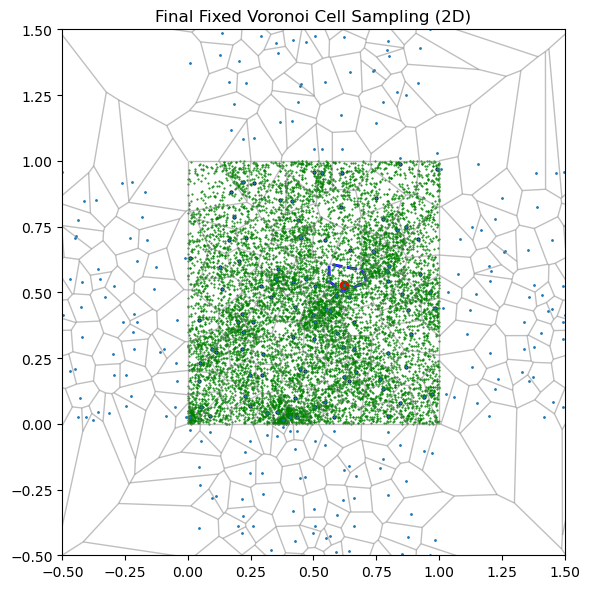

In [134]:
# Generate 100 random sites and sampler
sampler = VoronoiCellSamplerFixed(original_sites, bounds)

# Re-sample from cell 5
sampled_points = np.array([[sampler.sample_point_in_cell(i) for _ in range(100)] for i in original_indices] )

# Re-plot in 2D
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(original_sites[:, 0], original_sites[:, 1], 'ko', markersize=2)
ax.plot(original_sites[5, 0], original_sites[5, 1], 'ro', label='Cell Center')
region_index = sampler.vor.point_region[5]
region = sampler.vor.regions[region_index]
if -1 not in region:
    polygon = [sampler.vor.vertices[v] for v in region]
    polygon.append(polygon[0])
    poly = np.array(polygon)
    ax.plot(poly[:, 0], poly[:, 1], 'b--', lw=2, label='Voronoi Cell 5')
for i in range(len(original_sites)):
    ax.plot(sampled_points[i, :, 0], sampled_points[i, :, 1], 'g.', markersize=1, label='Samples')
voronoi_plot_2d(sampler.vor, ax=ax, show_vertices=False, line_colors='gray', line_width=1, line_alpha=0.5, point_size=2)

#ax.legend()
ax.set_title("Final Fixed Voronoi Cell Sampling (2D)")
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([-0.5, 1.5])
#plt.axis("equal")
plt.tight_layout()
plt.show()


[[1 1]
 [3 0]
 [4 2]
 [2 3]
 [0 2]]


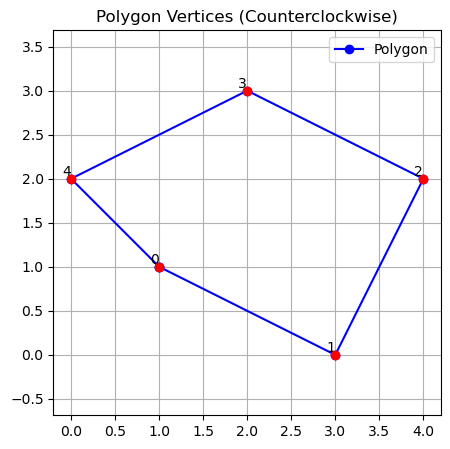

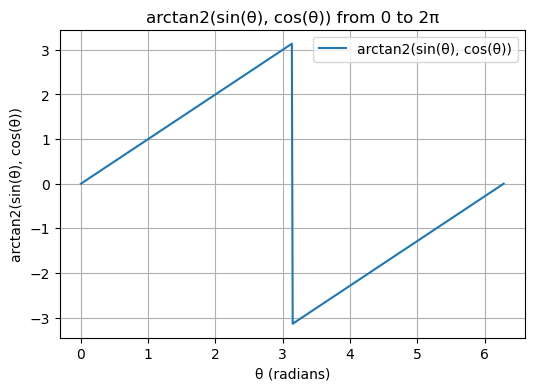

In [ ]:
import numpy as np

def sort_vertices_counterclockwise(points):
    """
    Sorts 2D convex polygon vertices counterclockwise.

    Parameters:
    - points: list of (x, y) tuples or Nx2 NumPy array

    Returns:
    - sorted_points: list of points in counterclockwise order
    """
    points = np.array(points)
    centroid = points.mean(axis=0)

    def angle(p):
        return np.arctan2(p[1] - centroid[1], p[0] - centroid[0])

    sorted_indices = np.argsort([angle(p) for p in points])
    return points[sorted_indices]

# Example:
vertices = [(1, 1), (2, 3), (4, 2), (3, 0), (0, 2)]
sorted_vertices = sort_vertices_counterclockwise(vertices)
print(sorted_vertices)
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
# Plot the polygon
polygon = np.vstack([sorted_vertices, sorted_vertices[0]])  # close the polygon
plt.plot(polygon[:, 0], polygon[:, 1], 'b-o', label='Polygon')
# Plot the vertices
plt.scatter(sorted_vertices[:, 0], sorted_vertices[:, 1], color='red', zorder=5)
for idx, (x, y) in enumerate(sorted_vertices):
    plt.text(x, y, str(idx), fontsize=10, ha='right', va='bottom')
plt.title('Polygon Vertices (Counterclockwise)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()



# Delta t

In [8]:
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.path.join(os.getcwd(), ".."), ".."))
sys.path.append(parent_dir)
from data_generation.models.general_ode_solver import GeneralODENumericalSolver
from data_generation.models.simple_test_models import *
from data_generation.simulations.simulator import Simulator
from data_generation.simulations.grid import *
from scipy.spatial import Voronoi, voronoi_plot_2d
import matplotlib.pyplot as plt

In [22]:
model = StableNode(control_params=["c"])
solver = GeneralODENumericalSolver(model)
bounds = [(-10,10), (-10,10)]
grid = VoronoiGrid(bounds, numbercells=30, padding_margin=1)
simulator = Simulator(grid, model, solver)

(99, 2)
(99, 2)
(99, 2)


In [38]:
centers, tf_centers, der, tf_der = simulator.get_gridcell_centers_and_derivatives(np.array([[1]]))

In [39]:
# Calculate the 2-norm (Euclidean norm) for each entry in tf_der
tf_der_norms = np.linalg.norm(tf_der, axis=-1)
cell_data = grid.get_complete_cell_data()


In [40]:
# For each cell, compute the average 'height' from the list of dicts in cell_data

avg_heights = np.zeros(grid.numbercells)
for cell_idx, facet_list in cell_data.items():
    heights = [facet['height'] for facet in facet_list]
    avg_heights[cell_idx] = np.mean(heights)

neighbor_range = np.column_stack([avg_heights, 3 * avg_heights])

def neighbor_transition_fraction(t):
    if t <= 0:
        return 0
    stretched_tf_der_norms = tf_der_norms * t
    # Calculate the fraction of cells that are within the neighbor range
    neighbor_fraction = np.sum((neighbor_range[:, 0] <= stretched_tf_der_norms) & (stretched_tf_der_norms <= neighbor_range[:, 1])) / grid.numbercells
    return neighbor_fraction
stretched_tf_der_norms = tf_der_norms * 0.5
print((neighbor_range[:, 0] <= stretched_tf_der_norms) & (stretched_tf_der_norms <= neighbor_range[:, 1]))
print(stretched_tf_der_norms)
print(neighbor_range)
# make an array of avg_heights in the same order as grid.indices
# compare with tf_der_norms
# calculate timestep multiplied with tf_der_norms
# get optimum overall timestep for the grid

[[ True  True  True  True  True False False  True False False  True  True
  False  True  True  True  True  True False]]
[[3.10209102 4.27671877 5.58980596 4.41266643 3.48948962 1.43928867
  2.12978052 5.43966981 2.19905828 2.16314642 4.10684168 5.91133316
  5.32527431 4.09815897 4.03976616 4.4078865  4.12055774 4.971272
  6.47468736]]
[[2.53373609 7.60120827]
 [2.252852   6.75855599]
 [2.40397912 7.21193737]
 [2.78086696 8.34260087]
 [2.36953957 7.10861872]
 [2.9344355  8.8033065 ]
 [2.17673831 6.53021492]
 [2.01772571 6.05317712]
 [2.80925364 8.42776092]
 [2.89184224 8.67552672]
 [3.16493941 9.49481822]
 [2.29355282 6.88065846]
 [1.74182557 5.22547672]
 [2.47138983 7.41416949]
 [2.73168943 8.19506829]
 [3.1395268  9.4185804 ]
 [1.94838428 5.84515285]
 [2.2284225  6.68526749]
 [1.73029763 5.19089289]]


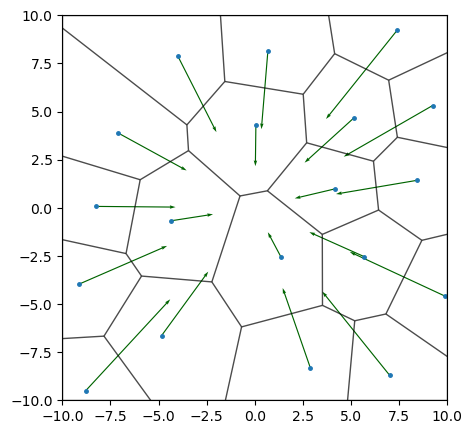

In [41]:
fig = plt.figure(figsize=(6, 6))
plt.quiver(
    tf_centers[:, 0], tf_centers[:, 1],  # start points
    0.5*tf_der[0, :, 0], 0.5*tf_der[0, :, 1],    # vector components
    angles='xy', scale_units='xy', scale=1, color='darkgreen', width=0.003, label='tf_der vectors'
)
#plt.scatter(tf_centers[:, 0], tf_centers[:, 1], color='b', label='tf_centers')
# Overlay the Voronoi diagram from the next cell on the same plot
voronoi_plot_2d(grid.voronoi, ax=plt.gca(), show_vertices=False, line_colors='black', line_width=1, line_alpha=0.7, point_size=5)

fig.set_size_inches(5, 5)
plt.xlim(bounds[0])
plt.ylim(bounds[1])
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

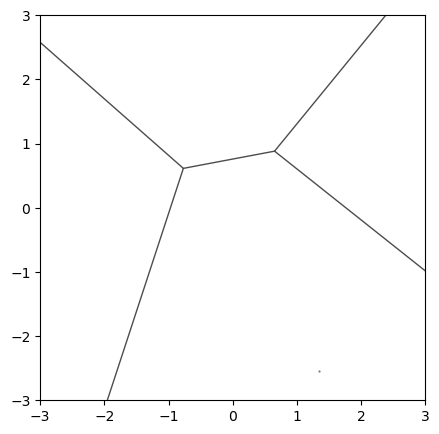

In [42]:
fig = voronoi_plot_2d(grid.voronoi, show_vertices=False, line_colors='black', line_width=1, line_alpha=0.7, point_size=1)
fig.set_size_inches(5, 5)
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()